Lutas REALIZADO: 811 | Período: 2015-2026
Decisivas: 802 | Title fights: 49

[Q1] Spearman (year vs duration, non-title): rho=0.086, p=0.01765, n=754

[Q2] Qui-quadrado pre/post-2020: chi2=3.36, p=0.339, V de Cramer=0.065, n=802

[Q3] Classes analisadas: 9
                      n    mean   std  median
weight_class_clean                           
Light Heavyweight    30  186.77  6.56  187.96
Heavyweight         166  186.66  6.25  187.96
Welterweight         24  179.70  3.29  180.34
Lightweight         228  175.14  4.00  175.26
Featherweight       302  173.63  3.90  172.72
Bantamweight        315  169.93  4.08  170.18
Flyweight           169  165.99  4.50  165.10
Catchweight         334  165.58  8.72  165.10
Strawweight          26  158.16  6.03  157.48

[Q4] Resultados por classe:
        group   n  win_rate  ci_low  ci_high  p_value  p_adjusted  significant
  Lightweight  90    0.6333  0.5302   0.7255   0.0149      0.0892        False
  Heavyweight  70    0.6143  0.4972   0.7195   0.0

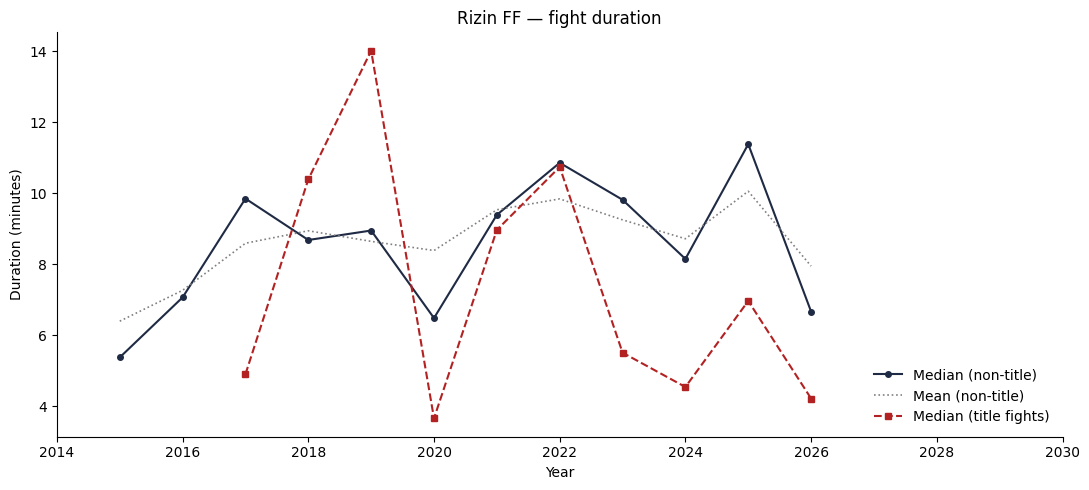

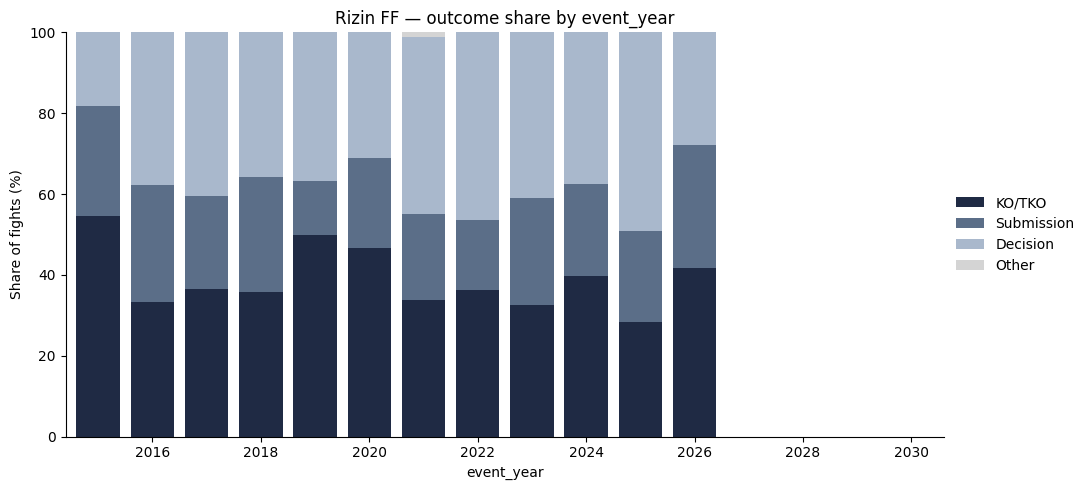

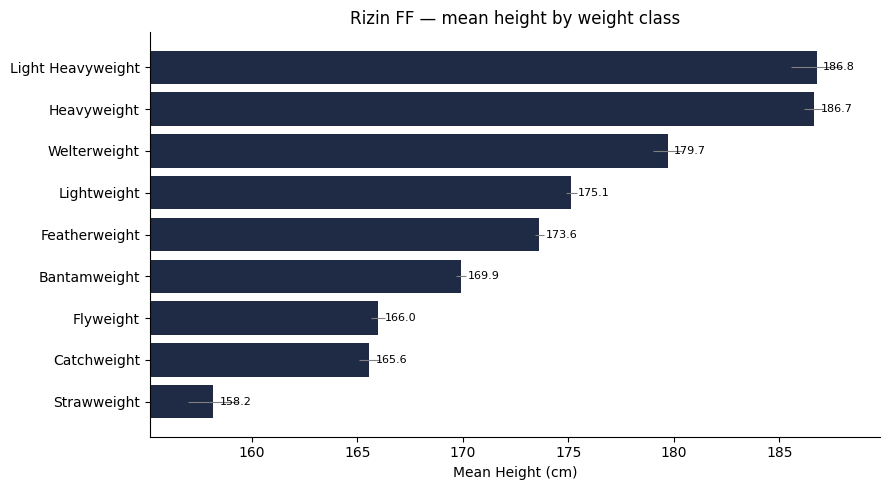

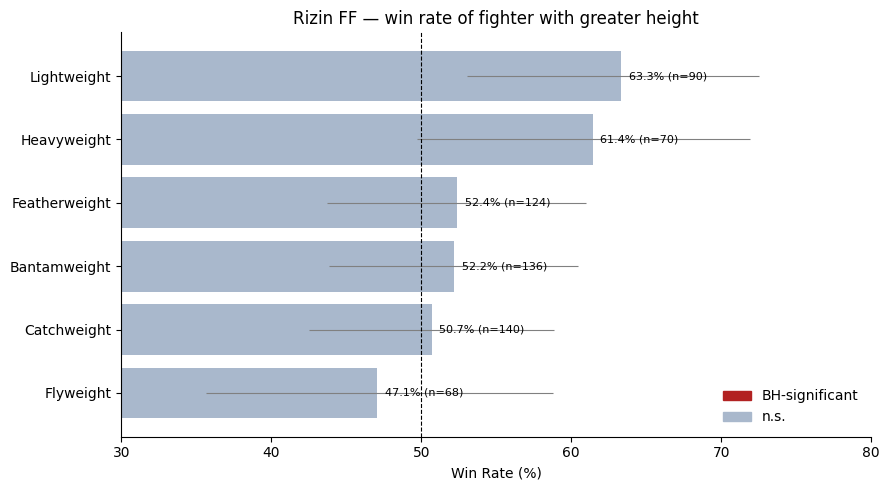

In [1]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm


DATA_DIR = '/kaggle/input/datasets/leandroiber/rizin-mma-dataset'
CSV_PATH = f'{DATA_DIR}/clean_sherdog_rizin.csv'
JSON_PATH = f'{DATA_DIR}/rizin_win_title_data.json'


def temporal_aggregation(df, time_col, value_col, group_col=None,
                         agg_funcs=('median', 'mean'), trend_test=True):
    funcs = list(agg_funcs) + ['count', 'std']
    if group_col is None:
        agg = df.groupby(time_col)[value_col].agg(funcs)
    else:
        agg = df.groupby([time_col, group_col])[value_col].agg(funcs).unstack()

    out = {'aggregation': agg}
    if trend_test:
        clean = df[[time_col, value_col]].dropna()
        if len(clean) > 3:
            rho, p = stats.spearmanr(clean[time_col], clean[value_col])
            out['spearman'] = {'rho': rho, 'p_value': p, 'n': len(clean)}
    return out


def categorical_composition_over_time(df, time_col, category_col,
                                      split_point=None, normalize=True):
    counts = df.groupby([time_col, category_col]).size().unstack(fill_value=0)
    proportions = counts.div(counts.sum(axis=1), axis=0) if normalize else counts

    out = {'proportions': proportions, 'counts': counts}

    if split_point is not None:
        before = df[df[time_col] < split_point][category_col].value_counts()
        after = df[df[time_col] >= split_point][category_col].value_counts()
        contingency = pd.DataFrame({'before': before, 'after': after}).fillna(0)
        chi2, p, dof, _ = stats.chi2_contingency(contingency)
        n = contingency.sum().sum()
        cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
        out['regime_test'] = {
            'chi2': chi2, 'p_value': p, 'dof': dof,
            'cramers_v': cramers_v, 'n': int(n),
            'contingency': contingency
        }
    return out


def group_descriptive(df, group_col, value_col, min_n=5):
    g = df.dropna(subset=[group_col, value_col]).groupby(group_col)[value_col]
    out = g.agg(['count', 'mean', 'std', 'median',
                 lambda x: x.quantile(0.25),
                 lambda x: x.quantile(0.75)])
    out.columns = ['n', 'mean', 'std', 'median', 'q25', 'q75']
    out['iqr'] = out['q75'] - out['q25']
    out = out[out['n'] >= min_n]
    return out.sort_values('mean', ascending=False)


def paired_advantage_test(df, group_col, attr_a_col, attr_b_col,
                          winner_is_a_col=None,
                          min_n=30, mc_method='fdr_bh', alpha=0.05):
    results = []
    for group, sub in df.groupby(group_col):
        sub = sub.dropna(subset=[attr_a_col, attr_b_col]).copy()
        if winner_is_a_col is not None:
            sub = sub.dropna(subset=[winner_is_a_col])
            a_won = sub[winner_is_a_col].astype(bool)
        else:
            a_won = pd.Series(True, index=sub.index)

        sub = sub[sub[attr_a_col] != sub[attr_b_col]]
        a_won = a_won.loc[sub.index]
        n = len(sub)

        if n < min_n:
            results.append({'group': group, 'n': n, 'underpowered': True})
            continue

        a_greater = sub[attr_a_col] > sub[attr_b_col]
        greater_won = (a_greater & a_won) | (~a_greater & ~a_won)
        wins = int(greater_won.sum())

        ci_low, ci_high = stats.binomtest(wins, n).proportion_ci(method='wilson')
        p_value = stats.binomtest(wins, n, p=0.5, alternative='two-sided').pvalue

        results.append({
            'group': group, 'n': n, 'win_rate': wins / n,
            'ci_low': ci_low, 'ci_high': ci_high,
            'p_value': p_value, 'underpowered': False
        })

    res = pd.DataFrame(results)
    res['p_adjusted'] = np.nan
    res['significant'] = False
    res['underpowered'] = res['underpowered'].astype(bool)

    valid = ~res['underpowered']
    if valid.sum() > 0:
        _, p_adj, _, _ = multipletests(res.loc[valid, 'p_value'],
                                       method=mc_method, alpha=alpha)
        res.loc[valid, 'p_adjusted'] = p_adj
        res.loc[valid, 'significant'] = p_adj < alpha
    return res.sort_values('win_rate', ascending=False, na_position='last')


def continuous_advantage_logit(df, group_col, diff_cols, target_col,
                               covariates=None, min_n=50):
    rows = []
    cols = list(diff_cols) + (covariates or [])
    for group, sub in df.groupby(group_col):
        sub = sub.dropna(subset=cols + [target_col])
        if len(sub) < min_n:
            continue
        X = sm.add_constant(sub[cols])
        y = sub[target_col].astype(int)
        try:
            m = sm.Logit(y, X).fit(disp=0)
            for c in cols:
                rows.append({
                    'group': group, 'predictor': c, 'n': len(sub),
                    'coef': m.params[c],
                    'odds_ratio': np.exp(m.params[c]),
                    'p_value': m.pvalues[c],
                    'or_ci_low': np.exp(m.conf_int().loc[c, 0]),
                    'or_ci_high': np.exp(m.conf_int().loc[c, 1]),
                    'pseudo_r2': m.prsquared
                })
        except Exception as e:
            rows.append({'group': group, 'error': str(e)})
    return pd.DataFrame(rows)


def load_rizin():
    df = pd.read_csv(CSV_PATH)
    df = df[df['event_status'] == 'REALIZADO'].copy()
    df['event_date'] = pd.to_datetime(df['event_date'], utc=True, errors='coerce')
    df['event_year'] = df['event_date'].dt.year

    def time_to_min(row):
        try:
            m, s = map(int, str(row['time']).split(':'))
            return (int(row['round_num']) - 1) * 5 + m + s / 60
        except (ValueError, TypeError):
            return np.nan
    df['duration_min'] = df.apply(time_to_min, axis=1)

    def bucket_method(m):
        if pd.isna(m):
            return np.nan
        m = m.lower()
        if 'submission' in m:
            return 'Submission'
        if 'ko' in m or 'tko' in m:
            return 'KO/TKO'
        if 'decision' in m:
            return 'Decision'
        return 'Other'
    df['method_bucket'] = df['method'].apply(bucket_method)

    df['weight_class_clean'] = df['weight_class'].apply(
        lambda x: 'Catchweight' if pd.notna(x) and re.search(r'Catch', str(x), re.I) else x
    )

    df['decisive'] = df['fighter_1_result'] == 'win'

    with open(JSON_PATH) as f:
        title_data = json.load(f)
    title_map = {}
    for k, v in title_data.items():
        key = (v.get('event_date'), v.get('fighter_1'), v.get('fighter_2'))
        title_map[key] = v.get('is_title_fight', False)
    df['_date_str'] = df['event_date'].dt.strftime('%Y-%m-%d')
    df['is_title_fight'] = df.apply(
        lambda r: title_map.get((r['_date_str'], r['fighter_1'], r['fighter_2']), False),
        axis=1
    )
    df = df.drop(columns=['_date_str'])
    return df


def q1_duration_over_time(df, x_max=2030):
    non_title = df[~df['is_title_fight'] & df['decisive']]
    title = df[df['is_title_fight'] & df['decisive']]

    nt_res = temporal_aggregation(non_title, 'event_year', 'duration_min')
    t_res = temporal_aggregation(title, 'event_year', 'duration_min', trend_test=False)

    fig, ax = plt.subplots(figsize=(11, 5))
    nt_agg = nt_res['aggregation']
    ax.plot(nt_agg.index, nt_agg['median'], '-o', color='#1f2a44',
            label='Median (non-title)', markersize=4)
    ax.plot(nt_agg.index, nt_agg['mean'], ':', color='gray',
            label='Mean (non-title)', linewidth=1.2)
    if len(t_res['aggregation']) > 0:
        t_agg = t_res['aggregation']
        ax.plot(t_agg.index, t_agg['median'], '--s', color='#b22222',
                label='Median (title fights)', markersize=4)
    ax.set_xlabel('Year')
    ax.set_ylabel('Duration (minutes)')
    ax.set_title('Rizin FF — fight duration')
    ax.legend(loc='lower right', frameon=False)
    ax.set_xlim(df['event_year'].min() - 1, x_max)
    sns.despine()
    plt.tight_layout()
    return fig, nt_res, t_res


def q2_outcome_share_over_time(df, split_year=2020, x_max=2030):
    decisive = df[df['decisive']].dropna(subset=['method_bucket'])
    res = categorical_composition_over_time(
        decisive, 'event_year', 'method_bucket', split_point=split_year
    )

    order = ['KO/TKO', 'Submission', 'Decision', 'Other']
    props = res['proportions'].reindex(columns=order, fill_value=0) * 100

    fig, ax = plt.subplots(figsize=(11, 5))
    palette = {'KO/TKO': '#1f2a44', 'Submission': '#5b6e88',
               'Decision': '#a9b8cc', 'Other': '#d4d4d4'}
    bottom = np.zeros(len(props))
    for cat in order:
        ax.bar(props.index, props[cat], bottom=bottom, label=cat, color=palette[cat])
        bottom += props[cat].values
    ax.set_xlabel('event_year')
    ax.set_ylabel('Share of fights (%)')
    ax.set_title('Rizin FF — outcome share by event_year')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
    ax.set_ylim(0, 100)
    ax.set_xlim(props.index.min() - 0.6, x_max + 0.6)
    sns.despine()
    plt.tight_layout()
    return fig, res


def q3_height_by_weight_class(df, min_n=10):
    valid_classes = df['weight_class_clean'].value_counts()
    valid_classes = valid_classes[valid_classes >= min_n].index
    sub = df[df['weight_class_clean'].isin(valid_classes)]

    long = pd.concat([
        sub[['weight_class_clean', 'f1_height_cm']].rename(columns={'f1_height_cm': 'height'}),
        sub[['weight_class_clean', 'f2_height_cm']].rename(columns={'f2_height_cm': 'height'})
    ])
    desc = group_descriptive(long, 'weight_class_clean', 'height', min_n=min_n)

    fig, ax = plt.subplots(figsize=(9, 5))
    desc_sorted = desc.sort_values('mean')
    ax.barh(desc_sorted.index, desc_sorted['mean'], color='#1f2a44',
            xerr=desc_sorted['std'] / np.sqrt(desc_sorted['n']),
            error_kw={'ecolor': 'gray', 'linewidth': 0.8})
    for i, (idx, row) in enumerate(desc_sorted.iterrows()):
        ax.text(row['mean'] + 0.3, i, f"{row['mean']:.1f}",
                va='center', fontsize=8)
    ax.set_xlabel('Mean Height (cm)')
    ax.set_title('Rizin FF — mean height by weight class')
    ax.set_xlim(desc_sorted['mean'].min() - 3, desc_sorted['mean'].max() + 3)
    sns.despine()
    plt.tight_layout()
    return fig, desc


def q4_height_advantage(df, min_n=30):
    sub = df[df['decisive']].dropna(
        subset=['f1_height_cm', 'f2_height_cm', 'weight_class_clean']
    ).copy()
    valid_classes = sub['weight_class_clean'].value_counts()
    sub = sub[sub['weight_class_clean'].isin(valid_classes[valid_classes >= min_n].index)]

    sub['winner_is_f1'] = True
    res = paired_advantage_test(
        sub, group_col='weight_class_clean',
        attr_a_col='f1_height_cm', attr_b_col='f2_height_cm',
        winner_is_a_col='winner_is_f1', min_n=min_n
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    valid = res[~res['underpowered']].copy()
    valid = valid.sort_values('win_rate')
    colors = ['#b22222' if s else '#a9b8cc' for s in valid['significant']]
    ax.barh(valid['group'], valid['win_rate'] * 100, color=colors,
            xerr=[(valid['win_rate'] - valid['ci_low']) * 100,
                  (valid['ci_high'] - valid['win_rate']) * 100],
            error_kw={'ecolor': 'gray', 'linewidth': 0.8})
    ax.axvline(50, ls='--', color='black', linewidth=0.8)
    for i, (_, row) in enumerate(valid.iterrows()):
        ax.text(row['win_rate'] * 100 + 0.5, i,
                f"{row['win_rate']*100:.1f}% (n={row['n']})",
                va='center', fontsize=8)
    ax.set_xlabel('Win Rate (%)')
    ax.set_title('Rizin FF — win rate of fighter with greater height')
    ax.set_xlim(30, 80)
    handles = [plt.Rectangle((0, 0), 1, 1, color='#b22222'),
               plt.Rectangle((0, 0), 1, 1, color='#a9b8cc')]
    ax.legend(handles, ['BH-significant', 'n.s.'], loc='lower right', frameon=False)
    sns.despine()
    plt.tight_layout()
    return fig, res


if __name__ == '__main__':
    df = load_rizin()
    print(f"Lutas REALIZADO: {len(df)} | Período: {df['event_year'].min()}-{df['event_year'].max()}")
    print(f"Decisivas: {df['decisive'].sum()} | Title fights: {df['is_title_fight'].sum()}")

    fig1, q1_nt, q1_t = q1_duration_over_time(df)
    fig1.savefig('q1_rizin_duration.png', dpi=120, bbox_inches='tight')
    print(f"\n[Q1] Spearman (year vs duration, non-title): "
          f"rho={q1_nt['spearman']['rho']:.3f}, "
          f"p={q1_nt['spearman']['p_value']:.4g}, "
          f"n={q1_nt['spearman']['n']}")

    fig2, q2 = q2_outcome_share_over_time(df, split_year=2020)
    fig2.savefig('q2_rizin_outcomes.png', dpi=120, bbox_inches='tight')
    rt = q2['regime_test']
    print(f"\n[Q2] Qui-quadrado pre/post-2020: "
          f"chi2={rt['chi2']:.2f}, p={rt['p_value']:.4g}, "
          f"V de Cramer={rt['cramers_v']:.3f}, n={rt['n']}")

    fig3, q3 = q3_height_by_weight_class(df, min_n=10)
    fig3.savefig('q3_rizin_height.png', dpi=120, bbox_inches='tight')
    print(f"\n[Q3] Classes analisadas: {len(q3)}")
    print(q3[['n', 'mean', 'std', 'median']].round(2))

    fig4, q4 = q4_height_advantage(df, min_n=30)
    fig4.savefig('q4_rizin_height_winrate.png', dpi=120, bbox_inches='tight')
    print(f"\n[Q4] Resultados por classe:")
    cols_show = ['group', 'n', 'win_rate', 'ci_low', 'ci_high', 'p_value', 'p_adjusted', 'significant']
    print(q4[cols_show].round(4).to_string(index=False))

## Q1 > Fight Duration Over Time
The series shows a slight upward drift in fight duration over time. The non-title median starts at 5.4 minutes in 2015, climbs to a range of 9-11 minutes from 2018 onward, with peaks at 2022 (10.8 min) and 2025 (11.4 min). The mean tracks just slightly above the median across the series, indicating a roughly symmetric distribution around the central tendency. The directional movement is consistent but the magnitude is small, and the year-to-year oscillation is wide enough that no single year defines the trend.

Title fights (red dashed line, n = 49 across 12 years) display extreme year-to-year volatility: an isolated spike to 14.0 minutes in 2019, a trough at 3.7 minutes in 2020, recovery to 9.7 minutes in 2022. With an average of roughly 4 title bouts per year, single fights move annual medians by 5 to 10 minutes. The series functions as a descriptive overlay, not a comparable signal.
The median sitting in the 9-11 minute range indicates that early finishes still account for a substantial portion of the card. If most fights were going to the time limit, the median would be pushed close to the regulation ceiling, which is not what the data shows.

## Q2 > Outcome Distribution Over Time

The outcome composition is statistically stable across the pre/post-2020 split. The test returns χ² = 3.36, p = 0.339, with Cramér's V = 0.065. There is no detectable association between period and outcome composition, and the effect size is negligible.

Year-by-year visual composition shows wide oscillation. KO/TKO ranges from roughly 28% (2025) to 55% (2015), submissions from 13% (2019) to 30% (2026), and decisions from 18% (2015) to 49% (2025). The 2025 datapoint is the highest decision share in the series and warrants individual scrutiny, since it may reflect a calendar weighted toward stylistic matchups or grand prix structures that produced more time-limit fights. The 2026 bar is built on incomplete data and should not be read as a regime signal.

Across the full window, KO/TKO accounts for roughly 38% of decisive fights, submissions for 22-25%, and decisions for 35-40%. The relatively high submission share is consistent with a roster drawing from the Japanese grappling tradition (catch wrestling, judo, BJJ), while the KO/TKO share reflects the striking-heavy lineage of regional Japanese MMA. The balance between the three outcome types is more even here than in promotions where decisions account for half or more of the card.

## Q3 > Mean Height by Weight Class
The ordinal progression breaks at the top of the table. Light Heavyweight (186.8 cm, n = 30) sits 0.1 cm above Heavyweight (186.7 cm, n = 166), so the two classes are statistically indistinguishable. The roster's height ceiling for both classes is roughly 188-190 cm, without the 195+ cm tail that would extend the Heavyweight distribution upward in a globally sourced sample.

The absolute height levels across all classes are shifted downward by a demographic effect. The East Asian population, and the Japanese population in particular, has a lower mean adult stature than the European, North American, and Slavic populations that dominate the heavier categories on the international circuit. Japanese male mean height sits around 171-172 cm, against roughly 178-181 cm for North American and Northern European males. This baseline difference propagates directly into the weight-class means: every division on the chart sits 2 to 4 cm below the equivalent class on a globally sourced roster, with the gap widening in the heavier classes where the absent 195+ cm tail matters most, and narrowing in the lighter divisions where the demographic effect is smaller in absolute terms.

The Catchweight bucket (165.6 cm, n = 334) is the largest category in the dataset and has by far the highest within-class standard deviation (8.72 cm vs 3-6 cm elsewhere). This is operationally distinctive: catchweight is used as a primary matchmaking instrument, not as an exception, and the bucket aggregates fighters across a very wide weight range. The mean lands between Flyweight and Bantamweight, which reflects the central tendency of the matched weights but masks an underlying multimodal distribution. The category should not be interpreted as a division in the conventional sense.

Welterweight (179.7 cm, n = 24) and Strawweight (158.2 cm, n = 26) sit at the threshold of the min_n = 10 filter and should be read with wide implicit confidence intervals. The sparse Welterweight sample suggests the class functions more as an occasional booking category than a structural weight class.

## Q4 > Win Rate by Height Advantage
Lightweight is the only class where the taller fighter shows a notable advantage. The win rate is 63.3% (n = 90, raw p = 0.0149), with Heavyweight following at 61.4% (n = 70, raw p = 0.0722). After correcting for multiple testing across the six classes, neither result survives the α = 0.05 threshold (adjusted p = 0.089 and 0.217 respectively). The formal conclusion is that the evidence is insufficient to reject the null hypothesis of no height effect, which is not the same as concluding that no effect exists.

The directional pattern across classes is worth examining. Lightweight and Heavyweight show point estimates 11 to 13 percentage points above the 50% baseline. Featherweight, Bantamweight, and Catchweight cluster within 3 points of the baseline (52.4%, 52.2%, 50.7%). Flyweight is the only class below the baseline at 47.1%. Lighter divisions tend to neutralize or reverse the height advantage, while middle-to-heavy divisions show the suggestive 55-65% range that does not clear correction at the current sample sizes.

The Lightweight raw p-value (0.0149) is informative for hypothesis sharpening rather than discarding. A pooled analysis at Lightweight specifically, combining multiple data sources, would be the logical next step. If the effect is real, the additional sample should push the corrected p-value below the threshold. If it is a small-sample fluctuation, the pooled estimate will regress toward 50%.
Catchweight (50.7%, n = 140) is essentially noise around the baseline, which is expected. When fighters are matched across a wide weight range, the height-advantage signal is confounded by the weight asymmetry of the bucket itself, and the comparison loses its conditional-on-weight interpretation.

Light Heavyweight, Welterweight, and Strawweight were excluded from the test due to insufficient sample after restricting to fights with both heights recorded (n < 30 in each). Including them would require either relaxing the threshold and accepting very wide confidence intervals, or waiting for additional events to accumulate.